In [1]:
!pip -q install causaldata causal-learn

import numpy as np
import pandas as pd
import networkx as nx
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from causaldata import nhefs
from causallearn.search.ConstraintBased.PC import pc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 56.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.9/245.9 kB 16.5 MB/s eta 0:00:00


# VERİ

In [2]:
T, O = "qsmk", "wt82_71"
C_cont = ["age", "smokeintensity", "smokeyrs", "wt71"]
C_cat  = ["sex", "race", "education", "exercise", "active"]
CONF   = C_cont + C_cat

df = nhefs.load_pandas().data[[O, T] + CONF]

print(df.describe(include="all").T)
print(df.groupby(T)[O].agg(["count", "mean", "std"]))
print("P(T=1):", df[T].mean())
print("Naive diff:", df.loc[df[T] == 1, O].mean() - df.loc[df[T] == 0, O].mean())

df = df.dropna().reset_index(drop=True)
for c in [O, T] + C_cont:
    df[c] = df[c].astype(float)
for c in C_cat:
    df[c] = df[c].astype(str)

                 count unique  top  freq       mean        std       min  \
wt82_71         1566.0    NaN  NaN   NaN     2.6383   7.879913 -41.28047   
qsmk            1629.0    NaN  NaN   NaN   0.262738   0.440256       0.0   
age             1629.0    NaN  NaN   NaN  43.915285   12.17043      25.0   
smokeintensity  1629.0    NaN  NaN   NaN  20.551258  11.803754       1.0   
smokeyrs        1629.0    NaN  NaN   NaN  24.871087  12.198072       1.0   
wt71            1629.0    NaN  NaN   NaN   71.05213   15.72959     36.17   
sex               1629      2    1   830        NaN        NaN       NaN   
race              1629      2    0  1414        NaN        NaN       NaN   
education         1629      5    3   659        NaN        NaN       NaN   
exercise          1629      3    1   677        NaN        NaN       NaN   
active            1629      3    1   738        NaN        NaN       NaN   

                     25%       50%       75%        max  
wt82_71        -1.478399  2.6

# MODEL

## Spesification

CPDAG directed  : [('wt82_71', 'qsmk'), ('age', 'qsmk'), ('smokeintensity', 'qsmk'), ('smokeyrs', 'qsmk'), ('race', 'qsmk'), ('age', 'wt82_71'), ('wt71', 'wt82_71'), ('age', 'smokeyrs'), ('sex', 'smokeintensity'), ('race', 'smokeintensity'), ('sex', 'smokeyrs'), ('sex', 'wt71'), ('race', 'wt71')]
CPDAG undirected: []
DAG edges  : [('qsmk', 'wt82_71'), ('age', 'qsmk'), ('age', 'wt82_71'), ('smokeintensity', 'qsmk'), ('smokeintensity', 'wt82_71'), ('smokeyrs', 'qsmk'), ('smokeyrs', 'wt82_71'), ('wt71', 'qsmk'), ('wt71', 'wt82_71'), ('sex', 'qsmk'), ('sex', 'wt82_71'), ('race', 'qsmk'), ('race', 'wt82_71'), ('education', 'qsmk'), ('education', 'wt82_71'), ('exercise', 'qsmk'), ('exercise', 'wt82_71'), ('active', 'qsmk'), ('active', 'wt82_71')]
DAG acyclic: True
SCE : C_j = f_Cj(U_Cj) ;  T = f_T(C, U_T) ;  O = f_O(T, C, U_O)
SCM : V = ['qsmk', 'wt82_71', 'age', 'smokeintensity', 'smokeyrs', 'wt71', 'sex', 'race', 'education', 'exercise', 'active']
      U = {U_T, U_O, U_Cj} ;  F = SCE ;  M

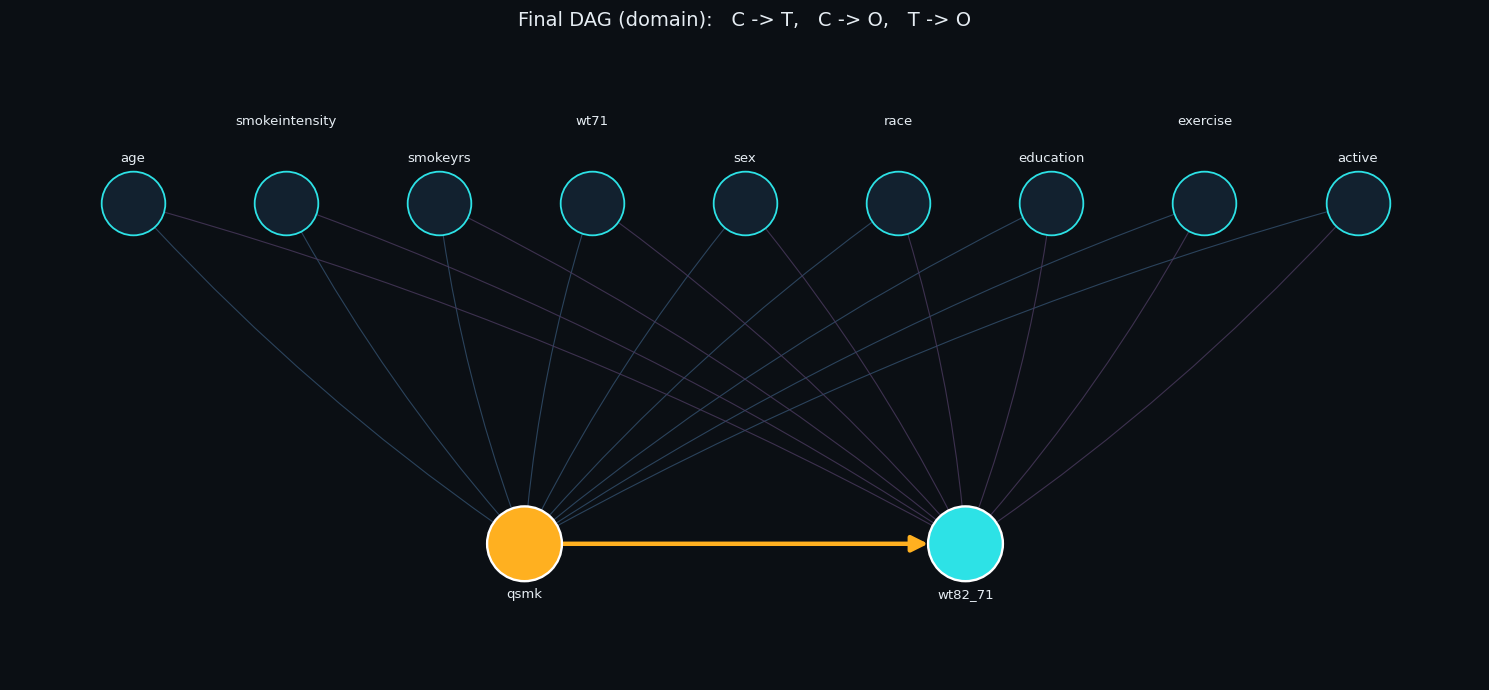

In [3]:
C_num = ["age", "smokeintensity", "smokeyrs", "wt71", "sex", "race"]
disc  = [T, O] + C_num
X = df[disc].astype(float).to_numpy()
cg = pc(X, alpha=0.05, indep_test="fisherz", show_progress=False, node_names=disc)
G = cg.G.graph
directed, undirected = [], []
for i in range(len(disc)):
    for j in range(i + 1, len(disc)):
        a, b = G[i, j], G[j, i]
        if a == -1 and b == 1:    directed.append((disc[i], disc[j]))
        elif a == 1 and b == -1:  directed.append((disc[j], disc[i]))
        elif a == -1 and b == -1: undirected.append((disc[i], disc[j]))
print("CPDAG directed  :", directed)
print("CPDAG undirected:", undirected)

D = nx.DiGraph()
D.add_nodes_from([T, O] + CONF)
for c in CONF:
    D.add_edge(c, T)
    D.add_edge(c, O)
D.add_edge(T, O)
print("DAG edges  :", list(D.edges()))
print("DAG acyclic:", nx.is_directed_acyclic_graph(D))
print("SCE : C_j = f_Cj(U_Cj) ;  T = f_T(C, U_T) ;  O = f_O(T, C, U_O)")
print("SCM : V =", [T, O] + CONF)
print("      U = {U_T, U_O, U_Cj} ;  F = SCE ;  M = (U, V, F, P(U))")

dsep = nx.is_d_separator if hasattr(nx, "is_d_separator") else nx.d_separated
Dm = D.copy()
Dm.remove_edges_from([(T, v) for v in list(D.successors(T))])
print("Backdoor set =", CONF)
print("  valid (T _||_ O | C in G_underline_T):", dsep(Dm, {T}, {O}, set(CONF)))
print("  C has no descendant of T:", len(set(CONF) & nx.descendants(D, T)) == 0)

k = len(CONF)
pos = {c: (i / (k - 1), 1.0) for i, c in enumerate(CONF)}
pos[T], pos[O] = (0.32, 0.0), (0.68, 0.0)
fig, ax = plt.subplots(figsize=(15, 7))
ax.set_facecolor("#0b0f14"); fig.patch.set_facecolor("#0b0f14")
nx.draw_networkx_edges(D, pos, edgelist=[(c, T) for c in CONF], edge_color="#33506e",
                       arrows=True, arrowsize=8, width=0.8, alpha=0.8, node_size=2100,
                       connectionstyle="arc3,rad=0.06", ax=ax)
nx.draw_networkx_edges(D, pos, edgelist=[(c, O) for c in CONF], edge_color="#4a3a5e",
                       arrows=True, arrowsize=8, width=0.8, alpha=0.8, node_size=2100,
                       connectionstyle="arc3,rad=-0.06", ax=ax)
nx.draw_networkx_edges(D, pos, edgelist=[(T, O)], edge_color="#ffb020",
                       arrows=True, arrowsize=24, width=3.2, node_size=2900, ax=ax)
nx.draw_networkx_nodes(D, pos, nodelist=CONF, node_color="#12212f", node_size=2100,
                       edgecolors="#2de2e6", linewidths=1.3, ax=ax)
nx.draw_networkx_nodes(D, pos, nodelist=[T, O], node_color=["#ffb020", "#2de2e6"],
                       node_size=2900, edgecolors="w", linewidths=1.7, ax=ax)
lp = {c: (pos[c][0], 1.13 if i % 2 == 0 else 1.24) for i, c in enumerate(CONF)}
lp[T], lp[O] = (0.32, -0.15), (0.68, -0.15)
nx.draw_networkx_labels(D, pos=lp, font_size=9.5, font_color="#e6edf3", ax=ax)
ax.set_title("Final DAG (domain):   C -> T,   C -> O,   T -> O", color="#e6edf3", fontsize=14, pad=18)
ax.set_ylim(-0.4, 1.45); ax.set_xlim(-0.1, 1.1); ax.axis("off")
plt.tight_layout(); plt.show()

## Identification

In [4]:
RHS = " + ".join(C_cont + [f"C({c})" for c in C_cat])
outcome = smf.ols(f"{O} ~ {T} + {RHS}", data=df).fit(cov_type="HC1")
d1 = df.assign(**{T: 1.0})
d0 = df.assign(**{T: 0.0})
mu1 = outcome.predict(d1)
mu0 = outcome.predict(d0)
ATE_ident = (mu1 - mu0).mean()
print("ATE (identification):", ATE_ident)

ATE (identification): 3.3811710339880965


## Estimation

In [5]:
b1 = outcome.params[T]
ci = outcome.conf_int().loc[T].values
ATE_est = b1
print(pd.Series({"ATE_est": ATE_est, "SE": outcome.bse[T], "t": outcome.tvalues[T],
                 "p": outcome.pvalues[T], "CI_low": ci[0], "CI_high": ci[1]}))

ATE_est    3.381171e+00
SE         4.734150e-01
t          7.142087e+00
p          9.192431e-13
CI_low     2.453295e+00
CI_high    4.309047e+00
dtype: float64


# DEĞERLENDİRME

## Sensitivity

                  beta_T    beta_O   ATE_adj  robust
var                                                 
age             0.053995 -1.790947  3.477873    True
smokeintensity -0.042057  0.230886  3.390881    True
smokeyrs        0.030967 -1.393706  3.424331    True
wt71            0.025624 -1.160856  3.410917    True
sex            -0.061102 -0.351335  3.359704    True
race           -0.095096 -0.391932  3.343900    True
   beta_T    beta_O   ATE_adj
0    -1.0 -5.071757 -1.690586
1    -1.0 -4.052308 -0.671137
2    -1.0 -3.032859  0.348312
3    -1.0 -2.013411  1.367760
4    -1.0 -0.993962  2.387209
5    -1.0  0.025486  3.406657
6    -1.0  1.044935  4.426106
7    -1.0  2.064383  5.445554
8    -1.0  3.083832  6.465003
9    -1.0  4.103280  7.484451


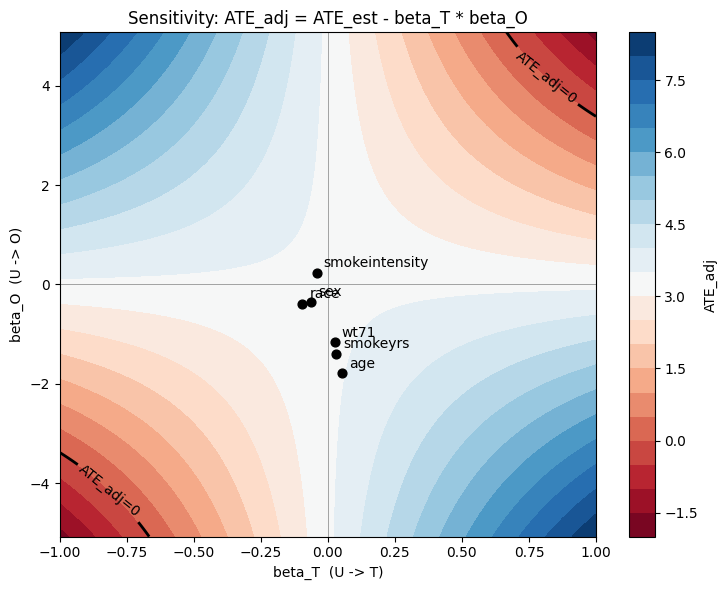

In [6]:
bench_vars = C_cont + ["sex", "race"]
Z = df.copy()
for c in C_cont:
    Z[c] = (Z[c] - Z[c].mean()) / Z[c].std()
for c in ["sex", "race"]:
    Z[c] = Z[c].astype(float)

rows = []
for c in bench_vars:
    bT = smf.ols(f"{T} ~ {c}", data=Z).fit().params[c]
    bO = smf.ols(f"{O} ~ {c}", data=Z).fit().params[c]
    adj = ATE_est - bT * bO
    robust = (np.sign(adj) == np.sign(ATE_est)) and (abs(adj) > 0.5 * abs(ATE_est))
    rows.append((c, bT, bO, adj, robust))
benchmark = pd.DataFrame(rows, columns=["var", "beta_T", "beta_O", "ATE_adj", "robust"]).set_index("var")
print(benchmark)

bT_max = max(1.0, 1.2 * benchmark.beta_T.abs().max())
bO_max = max(1.5 * abs(ATE_est), 1.2 * benchmark.beta_O.abs().max())
gT = np.linspace(-bT_max, bT_max, 200)
gO = np.linspace(-bO_max, bO_max, 200)
BT, BO = np.meshgrid(gT, gO)
ADJ = ATE_est - BT * BO
tablo = pd.DataFrame({"beta_T": BT.ravel(), "beta_O": BO.ravel(), "ATE_adj": ADJ.ravel()})
print(tablo.iloc[::4000].reset_index(drop=True))

plt.figure(figsize=(7.5, 6))
cf = plt.contourf(BT, BO, ADJ, levels=20, cmap="RdBu")
z0 = plt.contour(BT, BO, ADJ, levels=[0], colors="k", linewidths=2)
plt.clabel(z0, fmt="ATE_adj=0")
plt.colorbar(cf, label="ATE_adj")
plt.scatter(benchmark.beta_T, benchmark.beta_O, c="black", s=40, zorder=5)
for c in benchmark.index:
    plt.annotate(c, (benchmark.loc[c, "beta_T"], benchmark.loc[c, "beta_O"]),
                 textcoords="offset points", xytext=(5, 4))
plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("beta_T  (U -> T)")
plt.ylabel("beta_O  (U -> O)")
plt.title("Sensitivity: ATE_adj = ATE_est - beta_T * beta_O")
plt.tight_layout()
plt.show()